# Study 2: Normative Bayesian Predictions

This notebook derives what an ideal Bayesian observer would report in the Study 2
version of the diagnosis task. It uses the Bayesian network from
`JernRep-BayesNetModels.ipynb`, with the same nodes, CPDs, reliability support,
prior constructors, and pgmpy variable elimination, embedded in the Study 2 task.

Nothing is fitted and no data are read. Study 2 differs from Study 1 in four ways:

- the response scales;
- the chart (same content, different presentation);
- how the evidence is framed (one test, administered twice);
- the addition of agreeing trials.

No Study 1 estimates carry over. The screens do not state the test's reliability,
and participants' **initial beliefs about the test's reliability (θ)** are what
Study 2 is meant to estimate from their updates. The notebook therefore treats the
prior over θ as the unknown and maps every candidate prior onto the responses it
implies.

It follows five steps:

1. **Encode the Study 2 task**: the six cells, the two chart versions, the
   counterbalanced question framing, and reverse-coding on the 0–100% scale.
2. **The θ prior as the unknown**: Beta(a, b) on [0.25, 1), with a point mass
   (a single known θ) as the limiting case.
3. **Mapping each θ prior to predictions** for the final belief, the reliability
   judgment, and the belief change, in every cell.
4. **Conditioning on initial beliefs**: predictions as a function of the initial
   belief, plus a function that takes per-cell estimated marginal means of the
   initial belief, as in `JernRep-ModelPredictions.qmd`.
5. **Why the design can recover the θ prior**: priors that make identical
   predictions on conflicting results separate on agreeing results and on the
   reliability judgment.

**Reproducibility.** There is no randomness: all inference is exact, over a fixed
grid. The notebook writes its prediction tables to `data/processed/` under a
`JernRep-Study2-NormativePredictions-` prefix. Run it from `analysis/` or the
project root, in the same Python environment as `JernRep-BayesNetModels.ipynb`
(pgmpy, numpy, scipy, pandas, matplotlib).

# Step 1: The Study 2 task

## Screens

The screens (`JernRep-ExperimentScreens-Extension`) run as follows:

1. **Story.** A doctor is diagnosing a patient. A chart shows the percentage of
   previous patients with similar symptoms diagnosed with each of four diseases:
   two allozedic (A1, A2) and two hypozedic (H1, H2). Treatment depends on the
   disease class.
2. **Comprehension check.** Drag the four diseases into order of frequency.
3. **Initial belief.** "Given that the patient has one of the four possible
   diseases, what is the probability that the patient has an
   [allozedic / hypozedic] disease?" (0–100%).
4. **Evidence.** "The doctor administers a test that indicates which of the four
   possible diseases the patient has. The test is fairly accurate but can
   sometimes produce false results. […] the doctor administers the test twice."
   The first and second results are then shown.
5. **Final belief** (the same question as screen 3) and **reliability judgment**,
   in counterbalanced order. The reliability question reads: "Given that the
   patient has one of the four possible diseases, what is the probability that
   the test will accurately identify the disease they have?" (0–100%).

## What that means for the model

- **One test, one θ.** Both results come from the same test, so a single
  reliability θ governs both administrations. The two results are therefore
  evidence about the test as well as about the patient. Agreement is more likely
  when the test is reliable. Conflict means at least one administration was
  wrong.
- **No stated reliability.** The screens give only a verbal description, so the
  observer's prior over θ is a free quantity (Step 2).
- **Administrations are conditionally independent.** Given the true disease and
  θ, each administration is a separate draw. The model does not assume the test
  repeats its own mistake on this patient.
- **Reliability judgment = E[θ | results].** The question asks for the
  probability that the test identifies the true disease. For a Bayesian that is
  P(correct | θ) = θ averaged over what it now believes about θ, i.e. the
  posterior mean of θ.
- **Chart versions.** The two versions have the same frequencies (1% / 35% /
  40% / 24%) and differ only in which class is the more common one, so
  predictions are stated for the **more common class** and responses are
  reverse-coded to it.

In [1]:
## Setup
from pathlib import Path
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pgmpy
import scipy
from matplotlib.lines import Line2D
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
from scipy import stats
from scipy.optimize import brentq, least_squares

## Record the environment the outputs below were produced with
print(f"python {platform.python_version()} | pgmpy {pgmpy.__version__} | numpy {np.__version__} | "
      f"scipy {scipy.__version__} | pandas {pd.__version__} | matplotlib {matplotlib.__version__}")

## ---- Task constants ----
## Internal disease names follow JernRep-BayesNetModels.ipynb so the network code is unchanged:
## L1, L2 = diseases in the LESS common class; Y1, Y2 = diseases in the MORE common class.
DISEASES = ["L1", "L2", "Y1", "Y2"]
CLASSES = ["A", "H"]  ## internal labels: A = less common class, H = more common class
CLASS_OF = {"L1": "A", "L2": "A", "Y1": "H", "Y2": "H"}

## Chart frequencies (identical in both chart versions)
CHART_PRIOR = {"L1": 0.01, "L2": 0.35, "Y1": 0.40, "Y2": 0.24}
P_COMMON_CHART = sum(CHART_PRIOR[d] for d in DISEASES if CLASS_OF[d] == "H")  ## 0.64

## Reliability support: a four-outcome test answering at random is right 25% of the time, so
## theta < 0.25 would make the test anti-informative; the support is [0.25, 1) as in Study 1's notebook
THETA_FLOOR = 0.25
THETA_GRID = np.linspace(THETA_FLOOR, 0.999, 2000)

## Output location: data/processed/, found from analysis/ or the project root
PROJECT_ROOT = next(d for d in [Path.cwd(), Path.cwd().parent] if (d / "data").is_dir())
OUT_DIR = PROJECT_ROOT / "data" / "processed"
SAVE_CSV = True
SAVE_FIGURES = False  ## set True to write PNGs to materials/figures/
FIG_DIR = PROJECT_ROOT / "materials" / "figures"

## Plot palette, taken from the repository's existing result figures
INK, RUST, TEAL, ORANGE = "#303030", "#8B3A3A", "#3E7C91", "#F28F3B"

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.11/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


python 3.11.15 | pgmpy 1.1.2 | numpy 2.4.4 | scipy 1.17.1 | pandas 3.0.2 | matplotlib 3.10.9


## The six cells

Each cell is one pair of results (first, second). The order of the two results
does not matter to the observer, because the administrations are exchangeable
given the disease and θ.

| Cell | Slides (hypozedic-common chart) | Internal |
|---|---|---|
| Polarization × Conflict | H1 (40%), A1 (1%) | Y1, L1 |
| Polarization × Agree-Common | H1, H1 | Y1, Y1 |
| Polarization × Agree-Rare | A1, A1 | L1, L1 |
| Moderation × Conflict | H2 (24%), A2 (35%) | Y2, L2 |
| Moderation × Agree-Common | A2, A2 | L2, L2 |
| Moderation × Agree-Rare | H2, H2 | Y2, Y2 |

In the Moderation pair the individually more common disease (A2) is in the less
common class. That is why Moderation × Agree-Common pushes belief *away* from the
more common class.

In [2]:
CELLS = pd.DataFrame([
    ## Pair,          Evidence,        first, second
    ("Polarization", "Conflict",      "Y1", "L1"),
    ("Polarization", "Agree-Common",  "Y1", "Y1"),
    ("Polarization", "Agree-Rare",    "L1", "L1"),
    ("Moderation",   "Conflict",      "Y2", "L2"),
    ("Moderation",   "Agree-Common",  "L2", "L2"),
    ("Moderation",   "Agree-Rare",    "Y2", "Y2"),
], columns=["Pair", "Evidence", "T1", "T2"])
CELLS["Cell"] = CELLS["Pair"] + " × " + CELLS["Evidence"]
CELLS = CELLS.set_index("Cell")
PAIR_ORDER = ["Polarization", "Moderation"]
EVIDENCE_ORDER = ["Conflict", "Agree-Common", "Agree-Rare"]
CELL_ORDER = list(CELLS.index)


def evidence_of(cell):
    ## Network evidence for a cell: the results of the first and second administration
    row = CELLS.loc[cell]
    return {"T1": row["T1"], "T2": row["T2"]}


## Screen labels in each chart version. The hypozedic-common labels are the slides'; the
## allozedic-common labels (classes swapped, frequencies kept) are an assumption to check against
## the Qualtrics build. Predictions never depend on them.
CHART_VERSIONS = {
    "Hypozedic-common": {"common_class": "hypozedic", "labels": {"L1": "A1", "L2": "A2", "Y1": "H1", "Y2": "H2"}},
    "Allozedic-common": {"common_class": "allozedic", "labels": {"L1": "H1", "L2": "H2", "Y1": "A1", "Y2": "A2"}},
}

## Checks: frequencies sum to 1; conflicts span both classes; agree cells name the right disease twice
assert np.isclose(sum(CHART_PRIOR.values()), 1.0)
for cell, row in CELLS.iterrows():
    if row["Evidence"] == "Conflict":
        assert {CLASS_OF[row["T1"]], CLASS_OF[row["T2"]]} == {"A", "H"}
    else:
        common, rare = {"Polarization": ("Y1", "L1"), "Moderation": ("L2", "Y2")}[row["Pair"]]
        assert row["T1"] == row["T2"] == (common if row["Evidence"] == "Agree-Common" else rare)
        assert CHART_PRIOR[common] > CHART_PRIOR[rare]

view = CELLS.copy()
for version, spec in CHART_VERSIONS.items():
    view[f"Screen ({version})"] = [f"{spec['labels'][a]}, {spec['labels'][b]}" for a, b in zip(view["T1"], view["T2"])]
view

,Pair,Evidence,T1,T2,Screen (Hypozedic-common),Screen (Allozedic-common)
Cell,,,,,,
Polarization × Conflict,Polarization,Conflict,Y1,L1,"H1, A1","A1, H1"
Polarization × Agree-Common,Polarization,Agree-Common,Y1,Y1,"H1, H1","A1, A1"
Polarization × Agree-Rare,Polarization,Agree-Rare,L1,L1,"A1, A1","H1, H1"
Moderation × Conflict,Moderation,Conflict,Y2,L2,"H2, A2","A2, H2"
Moderation × Agree-Common,Moderation,Agree-Common,L2,L2,"A2, A2","H2, H2"
Moderation × Agree-Rare,Moderation,Agree-Rare,Y2,Y2,"H2, H2","A2, A2"


## Response scale and reverse-coding

Both questions are answered as a percentage. The belief question names
allozedic or hypozedic at random. A response about the less common class is
reverse-coded (100 − x) to the more common class, as `Choice` was in the Study 1
R pipeline. The reliability question names no class and is never reverse-coded.

In [3]:
def to_pct(p):
    ## Probability -> 0..100% response scale
    return 100 * np.asarray(p, dtype=float)


def from_pct(x):
    ## 0..100% response -> probability
    return np.asarray(x, dtype=float) / 100


def reverse_code_belief(response_pct, question_class, chart_version):
    ## Raw belief response -> belief in the MORE COMMON class (0..100%); vectorized over rows
    common = np.array([CHART_VERSIONS[v]["common_class"] for v in np.atleast_1d(chart_version)])
    response_pct = np.asarray(response_pct, dtype=float)
    return np.where(np.asarray(question_class) == common, response_pct, 100 - response_pct)


def to_raw_belief(common_pct, question_class, chart_version):
    ## Belief in the more common class -> response to the question as framed (the map is its own inverse)
    return reverse_code_belief(common_pct, question_class, chart_version)


for version in CHART_VERSIONS:
    for q in ["allozedic", "hypozedic"]:
        x = np.array([10.0, 64.0, 90.0])
        assert np.allclose(reverse_code_belief(to_raw_belief(x, [q] * 3, [version] * 3), [q] * 3, [version] * 3), x)

## Counterbalancing map for data processing: every combination and whether belief is reverse-coded
design_map = pd.DataFrame([
    {"Cell": cell, "ChartVersion": v, "QuestionClass": q, "ScreenOrder": o,
     "First_screen": spec["labels"][CELLS.loc[cell, "T1"]], "Second_screen": spec["labels"][CELLS.loc[cell, "T2"]],
     "ReverseCodeBelief": q != spec["common_class"]}
    for cell in CELL_ORDER for v, spec in CHART_VERSIONS.items()
    for q in ["allozedic", "hypozedic"] for o in ["Belief first", "Reliability first"]
])
print(f"{len(design_map)} between-subjects combinations")
design_map.head(4)

48 between-subjects combinations


,Cell,ChartVersion,QuestionClass,ScreenOrder,First_screen,Second_screen,ReverseCodeBelief
0,Polarization × Conflict,Hypozedic-common,allozedic,Belief first,H1,A1,True
1,Polarization × Conflict,Hypozedic-common,allozedic,Reliability first,H1,A1,True
2,Polarization × Conflict,Hypozedic-common,hypozedic,Belief first,H1,A1,False
3,Polarization × Conflict,Hypozedic-common,hypozedic,Reliability first,H1,A1,False


## The network

The structure is the Study 1 disease-level network, with one θ shared by both
administrations:

    Theta -> T1 <- D -> C
    Theta -> T2 <- D

- P(T = t | D, θ) = θ if t = D, else (1 − θ)/3.
- `C` is a deterministic readout of `D`'s class.
- The disease prior P(D) is the chart, rescaled to the observer's initial class
  belief when predictions are conditioned on it (Step 4).

The construction code below is copied from `JernRep-BayesNetModels.ipynb`.

In [4]:
## ---- Network construction (verbatim from JernRep-BayesNetModels.ipynb) ----
def _theta_cpd(grid, weights):
    weights = np.asarray(weights, dtype=float)
    return TabularCPD(
        "Theta", len(grid), weights.reshape(-1, 1) / weights.sum(),
        state_names={"Theta": [float(v) for v in grid]},
    )


def _disease_cpds(prior_D):
    p = np.array([prior_D[d] for d in DISEASES], dtype=float)
    cpd_D = TabularCPD("D", 4, (p / p.sum()).reshape(-1, 1), state_names={"D": DISEASES})
    ## C is a deterministic readout of D's class
    cpd_C = TabularCPD(
        "C", 2, [[1.0 if CLASS_OF[d] == c else 0.0 for d in DISEASES] for c in CLASSES],
        evidence=["D"], evidence_card=[4], state_names={"C": CLASSES, "D": DISEASES},
    )
    return cpd_D, cpd_C


def _test_cpd(test, parent, parent_states, grid, accuracy=None):
    ## Accuracy when the result matches the parent's state; remainder split evenly over the other outcomes
    grid = np.asarray(grid, dtype=float)
    acc = grid if accuracy is None else np.asarray(accuracy, dtype=float)
    k = len(parent_states)
    blocks = []
    for i in range(k):  ## Columns: parent-major blocks of theta slots
        block = np.tile((1 - acc) / (k - 1), (k, 1))
        block[i] = acc
        blocks.append(block)
    return TabularCPD(
        test, k, np.hstack(blocks),
        evidence=[parent, "Theta"], evidence_card=[k, len(grid)],
        state_names={test: parent_states, parent: parent_states,
                     "Theta": [float(v) for v in grid]},
    )


def _make_disease_level_network(prior_D, theta_grid, theta_weights):
    net = DiscreteBayesianNetwork(
        [("D", "C"), ("D", "T1"), ("D", "T2"), ("Theta", "T1"), ("Theta", "T2")]
    )
    net.add_cpds(
        *_disease_cpds(prior_D), _theta_cpd(theta_grid, theta_weights),
        _test_cpd("T1", "D", DISEASES, theta_grid),
        _test_cpd("T2", "D", DISEASES, theta_grid),
    )
    net.check_model()
    return net


def make_study2_network(prior_D, theta_grid, theta_weights):
    ## Study 2: T1 and T2 are the first and second administration of the same test (one shared Theta)
    return _make_disease_level_network(prior_D, theta_grid, theta_weights)


def class_prior(p_common, base=CHART_PRIOR):
    ## Disease prior whose class totals match a class-level belief, within-class ratios fixed at the chart's
    ## (the `empirical_prior` of JernRep-BayesNetModels.ipynb)
    p_base = sum(base[d] for d in DISEASES if CLASS_OF[d] == "H")
    scale = {"A": (1 - p_common) / (1 - p_base), "H": p_common / p_base}
    return {d: base[d] * scale[CLASS_OF[d]] for d in DISEASES}

## Inference

`predict` returns the class belief before and after the results and the prior and
posterior mean of θ. `predict_batch` computes the same quantities for many initial
beliefs at once, by exact enumeration over (D, θ). It is used for the dense grids
in Steps 3–5, and the cell after it checks that it matches pgmpy to machine
precision.

In [5]:
def _query(infer, variables, evidence=None):
    try:
        return infer.query(variables=variables, evidence=evidence, show_progress=False)
    except TypeError:  ## pgmpy versions without show_progress
        return infer.query(variables=variables, evidence=evidence)


def predict(network, evidence):
    ## Exact inference: belief in the more common class and E[theta], before and after the results
    infer = VariableElimination(network)
    prior_C, post_C = _query(infer, ["C"]), _query(infer, ["C"], evidence)
    prior_theta, post_theta = _query(infer, ["Theta"]), _query(infer, ["Theta"], evidence)
    grid = np.array(post_theta.state_names["Theta"], dtype=float)
    return {"p_initial": float(prior_C.get_value(C="H")), "p_final": float(post_C.get_value(C="H")),
            "rel_initial": float(np.sum(grid * prior_theta.values)), "rel_final": float(np.sum(grid * post_theta.values))}


def predict_cell(cell, p_initial, theta_prior):
    ## pgmpy prediction for one cell, from an initial class belief and a theta prior (grid, weights)
    grid, weights = theta_prior
    return predict(make_study2_network(class_prior(p_initial), grid, weights), evidence_of(cell))


IS_H = np.array([CLASS_OF[d] == "H" for d in DISEASES])
CHART_VEC = np.array([CHART_PRIOR[d] for d in DISEASES])


def predict_batch(cell, p_initial, theta_prior):
    ## Same quantities as predict_cell for a vector of initial class beliefs (exact enumeration)
    grid, weights = theta_prior
    grid = np.asarray(grid, dtype=float)
    w = np.asarray(weights, dtype=float) / np.sum(weights)
    p0 = np.atleast_1d(np.asarray(p_initial, dtype=float))
    scale = np.where(IS_H[None, :], p0[:, None] / P_COMMON_CHART, (1 - p0[:, None]) / (1 - P_COMMON_CHART))
    prior = CHART_VEC[None, :] * scale                                  ## n x 4 disease priors
    lik = np.ones((4, len(grid)))
    for t in evidence_of(cell).values():                               ## both administrations share theta
        lik *= np.array([np.where(d == t, grid, (1 - grid) / 3) for d in DISEASES])
    lik_w = lik * w[None, :]
    mass_D = prior * lik_w.sum(axis=1)[None, :]
    Z = mass_D.sum(axis=1)
    return {"p_initial": p0, "p_final": mass_D[:, IS_H].sum(axis=1) / Z,
            "rel_initial": np.full_like(p0, np.sum(w * grid)),
            "rel_final": (prior @ (lik_w * grid[None, :])).sum(axis=1) / Z}

# Step 2: The θ prior as the unknown

The observer's prior over θ is what Study 2 is designed to estimate. As in
`JernRep-BayesNetModels.ipynb`, a θ prior is a `(grid, weights)` pair:

- **Beta(a, b), truncated to [0.25, 1)**: the observer is uncertain about the
  test and infers θ jointly with the diagnosis.
- **Point mass at θ₀**: the observer treats the test's reliability as known.
  This is the limit of a Beta whose spread goes to zero.

To lay out predictions readably, each Beta in the grid below is chosen so that
its truncated **mean** and **SD** hit target values. This is only a way of indexing
the grid. The prior is still Beta(a, b), and every row of the output records its
(a, b).

- Means run from 0.30 to 0.95.
- SDs are 0 (point mass), 0.05, 0.10, 0.15, and 0.20.
- Combinations that no Beta on [0.25, 1) can produce are dropped, e.g. a
  mean of 0.95 with an SD of 0.20.

In [6]:
## ---- Prior constructors (verbatim from JernRep-BayesNetModels.ipynb) ----
def point_mass_prior(value):
    ## Theta prior with all mass on a single reliability value
    return np.array([value]), np.array([1.0])


def beta_prior(a, b, grid=THETA_GRID):
    ## Beta(a, b) theta prior, discretized (and thereby truncated) to grid
    with np.errstate(divide="ignore", invalid="ignore"):
        weights = stats.beta.pdf(grid, a, b)
        return grid, weights / weights.sum()


def prior_moments(theta_prior):
    grid, w = theta_prior[0], theta_prior[1] / theta_prior[1].sum()
    mean = float(np.sum(w * grid))
    return mean, float(np.sqrt(np.sum(w * (grid - mean) ** 2)))


def beta_for_moments(mean, sd):
    ## (a, b) whose Beta truncated to THETA_GRID has the target mean and sd, or None if unreachable
    def resid(log_ab):
        m, s = prior_moments(beta_prior(*np.exp(log_ab)))
        return [m - mean, s - sd]
    ## Start from the untruncated moment-matched Beta (clipped into bounds), then correct for truncation;
    ## a second start from a flat Beta covers cases where truncation moves the solution far away
    lo, hi = np.log(0.05), np.log(5000)
    nu = max(mean * (1 - mean) / sd ** 2 - 1, 0.5)
    for start in [np.log([mean * nu, (1 - mean) * nu]), np.log([1.0, 1.0]), np.log([0.5, 5.0]), np.log([5.0, 0.5])]:
        fit = least_squares(resid, np.clip(start, lo + 1e-6, hi - 1e-6), bounds=(lo, hi))
        a, b = np.exp(fit.x)
        m, s = prior_moments(beta_prior(a, b))
        if abs(m - mean) < 1e-3 and abs(s - sd) < 1e-3:
            return float(a), float(b)
    return None


PRIOR_MEANS = np.round(np.arange(0.30, 0.951, 0.05), 2)
PRIOR_SDS = [0.0, 0.05, 0.10, 0.15, 0.20]

theta_priors = []   ## one dict per candidate prior
for sd in PRIOR_SDS:
    for mean in PRIOR_MEANS:
        if sd == 0:
            theta_priors.append({"family": "Point mass", "a": np.nan, "b": np.nan, "mean": mean, "sd": 0.0,
                                 "prior": point_mass_prior(mean)})
            continue
        ab = beta_for_moments(mean, sd)
        if ab is not None:
            theta_priors.append({"family": "Beta", "a": ab[0], "b": ab[1], "mean": mean, "sd": sd,
                                 "prior": beta_prior(*ab)})

prior_table = pd.DataFrame([{k: v for k, v in p.items() if k != "prior"} for p in theta_priors])
print(f"{len(theta_priors)} candidate theta priors")
prior_table.pivot_table(index="mean", columns="sd", values="family", aggfunc="count").fillna(0).astype(int).T

55 candidate theta priors


mean,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95
sd,,,,,,,,,,,,,,
0.00,1,1,1,1,1,1,1,1,1,1,1,1,1,1
0.05,0,1,1,1,1,1,1,1,1,1,1,1,1,1
0.10,0,0,1,1,1,1,1,1,1,1,1,1,1,0
0.15,0,0,0,1,1,1,1,1,1,1,1,1,1,0
0.20,0,0,0,0,0,1,1,1,1,1,1,1,0,0


The table shows which (mean, SD) combinations exist on [0.25, 1): 1 means a prior
was found, 0 means none exists. Wide priors are impossible at the extremes,
because the support is bounded at 0.25 and 1.

In [7]:
## Validation: predict_batch reproduces the pgmpy network on every cell for a spread of theta priors
check = [p for p in theta_priors if (p["mean"], p["sd"]) in {(0.5, 0.0), (0.7, 0.1), (0.6, 0.2), (0.9, 0.05)}]
worst = 0.0
for cell in CELL_ORDER:
    for p in check:
        fast = predict_batch(cell, np.array([0.2, P_COMMON_CHART, 0.9]), p["prior"])
        for i, p0 in enumerate([0.2, P_COMMON_CHART, 0.9]):
            slow = predict_cell(cell, p0, p["prior"])
            worst = max(worst, *(abs(slow[k] - fast[k][i]) for k in slow))
print(f"max |pgmpy - enumeration| = {worst:.2e} over {len(CELL_ORDER) * len(check) * 3} checks")
assert worst < 1e-10

max |pgmpy - enumeration| = 4.44e-16 over 72 checks


# Step 3: From a θ prior to predicted responses

For every candidate θ prior and every cell, the observer starting from the chart
(64% on the more common class) predicts:

- **Final belief**: P(more common class | results), in %.
- **Belief change**: final − initial, in percentage points.
- **Reliability judgment**: E[θ | results], in %.
- **Reliability change**: E[θ | results] − E[θ], the shift from the observer's
  initial belief about the test. This is a model quantity. The screens ask about
  reliability only after the results, so a participant's reliability *change* is
  not directly observed.

In [8]:
def predictions_for(p_initial, priors=theta_priors, cells=CELL_ORDER):
    ## Long table: one row per (theta prior, cell, initial belief)
    p_initial = np.atleast_1d(p_initial)
    rows = []
    for p in priors:
        for cell in cells:
            out = predict_batch(cell, p_initial, p["prior"])
            for i, p0 in enumerate(p_initial):
                rows.append({"family": p["family"], "a": p["a"], "b": p["b"], "prior_mean": p["mean"],
                             "prior_sd": p["sd"], "Cell": cell, "Pair": CELLS.loc[cell, "Pair"],
                             "Evidence": CELLS.loc[cell, "Evidence"],
                             "Belief_initial": to_pct(p0), "Belief_final": to_pct(out["p_final"][i]),
                             "Reliability_prior": to_pct(out["rel_initial"][i]),
                             "Reliability_final": to_pct(out["rel_final"][i])})
    df = pd.DataFrame(rows)
    df["Belief_change"] = df["Belief_final"] - df["Belief_initial"]
    df["Reliability_change"] = df["Reliability_final"] - df["Reliability_prior"]
    return df


chart_preds = predictions_for(P_COMMON_CHART)
print(f"{len(chart_preds)} predictions at the chart prior")

## A readable slice: three prior means, known vs. moderately uncertain reliability
slice_ = chart_preds[chart_preds["prior_mean"].isin([0.5, 0.7, 0.9]) & chart_preds["prior_sd"].isin([0.0, 0.1])]
slice_.pivot_table(index="Cell", columns=["prior_mean", "prior_sd"],
                   values=["Belief_final", "Reliability_final"], sort=False).reindex(CELL_ORDER).round(1)

330 predictions at the chart prior


Belief_final                                \
prior_mean                           0.5   0.7   0.9   0.5   0.7   0.9   
prior_sd                             0.0   0.0   0.0   0.1   0.1   0.1   
Cell                                                                     
Polarization × Conflict             79.1  87.9  94.7  78.1  86.6  91.5   
Polarization × Agree-Common         91.4  98.2  99.9  91.4  98.1  99.8   
Polarization × Agree-Rare           59.3  43.2   7.7  59.3  44.4  13.7   
Moderation × Conflict               51.4  45.8  42.1  52.1  46.6  43.8   
Moderation × Agree-Common           16.8   3.6   0.3  16.8   3.9   0.5   
Moderation × Agree-Rare             87.7  97.1  99.8  87.7  96.9  99.6   

                            Reliability_final                                
prior_mean                                0.5   0.7   0.9   0.5   0.7   0.9  
prior_sd                                  0.0   0.0   0.0   0.1   0.1   0.1  
Cell                                                                         
Polarization × Conflict                  50.0  70.0  90.0  48.7  67.3  80.9  
Polarization × Agree-Common              50.0  70.0  90.0  52.8  72.4  91.9  
Polarization × Agree-Rare                50.0  70.0  90.0  46.8  66.5  87.7  
Moderation × Conflict                    50.0  70.0  90.0  49.2  67.7  81.5  
Moderation × Agree-Common                50.0  70.0  90.0  52.6  72.4  91.9  
Moderation × Agree-Rare                  50.0  70.0  90.0  51.9  72.1  91.8

## Figure: predictions against the prior mean of θ

Each panel is one cell and the x-axis is the observer's prior mean reliability.
Line shade marks the prior SD, from black (a point mass, i.e. known reliability)
to the lightest (SD = 0.20). The top block shows the final belief and the bottom
block the reliability judgment.

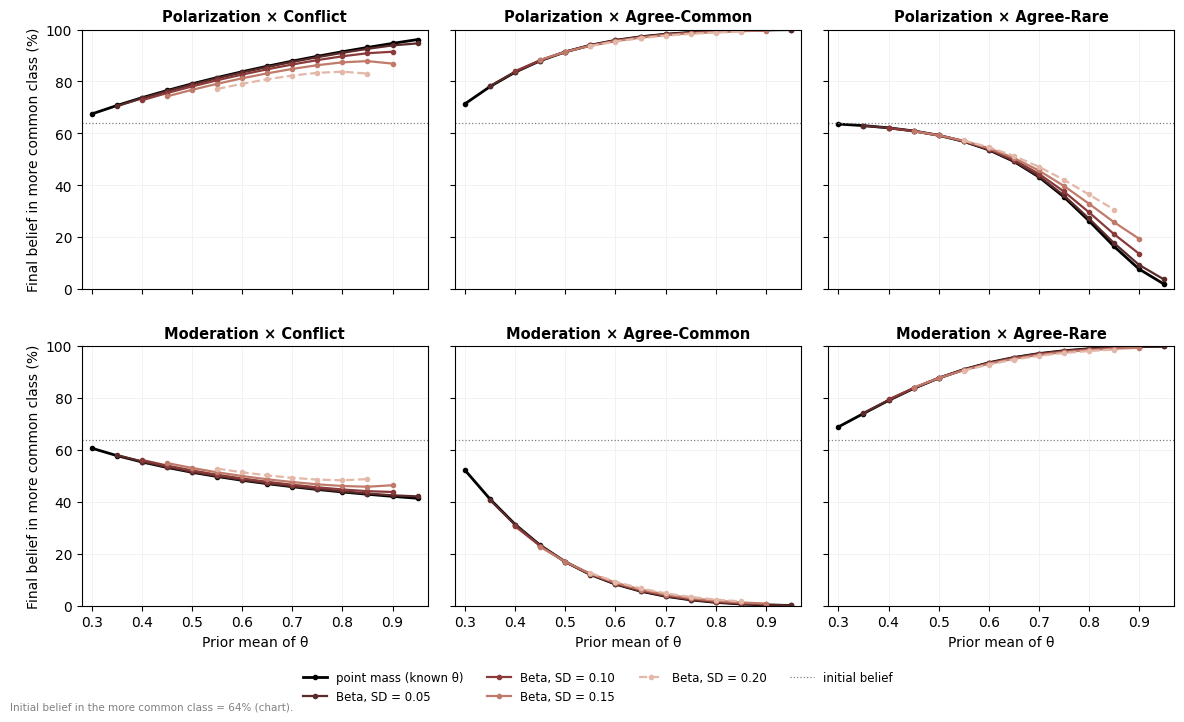

In [9]:
SD_COLORS = dict(zip(PRIOR_SDS, ["#000000", "#5b2a2a", "#8B3A3A", "#c07a6a", "#e3b8a8"]))


def plot_vs_prior_mean(df, dv, ylabel, reference=None, fname=None):
    fig, axes = plt.subplots(2, 3, figsize=(12, 7.2), sharex=True, sharey=True)
    for r_i, pair in enumerate(PAIR_ORDER):
        for c_i, ev in enumerate(EVIDENCE_ORDER):
            ax, cell = axes[r_i, c_i], f"{pair} × {ev}"
            for sd in PRIOR_SDS:
                sub = df[(df["Cell"] == cell) & (df["prior_sd"] == sd)].sort_values("prior_mean")
                ax.plot(sub["prior_mean"], sub[dv], color=SD_COLORS[sd], lw=2 if sd == 0 else 1.6,
                        ls="-" if sd == 0 else "--" if sd == 0.2 else "-", marker="o", ms=3,
                        label="point mass (known θ)" if sd == 0 else f"Beta, SD = {sd:.2f}")
            if reference == "identity":
                ax.plot([0.25, 1], [25, 100], color="gray", ls=":", lw=0.9, label="= prior mean")
            elif reference is not None:
                ax.axhline(reference, color="gray", ls=":", lw=0.9, label="initial belief")
            ax.set_title(cell, fontsize=10.5, fontweight="bold")
            ax.set_ylim(0, 100); ax.set_xlim(0.28, 0.97)
            ax.grid(color="0.94", lw=0.6); ax.set_axisbelow(True)
            if r_i == 1:
                ax.set_xlabel("Prior mean of θ")
        axes[r_i, 0].set_ylabel(ylabel)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, 0.0))
    fig.text(0.01, 0.005, "Initial belief in the more common class = 64% (chart).", fontsize=7.5, color="gray")
    fig.subplots_adjust(bottom=0.15, left=0.07, right=0.98, top=0.95, hspace=0.22, wspace=0.08)
    if SAVE_FIGURES and fname:
        fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches="tight")
    return fig


fig = plot_vs_prior_mean(chart_preds, "Belief_final", "Final belief in more common class (%)",
                         reference=to_pct(P_COMMON_CHART), fname="JernRep-Study2-Normative-Belief-byPrior.png")

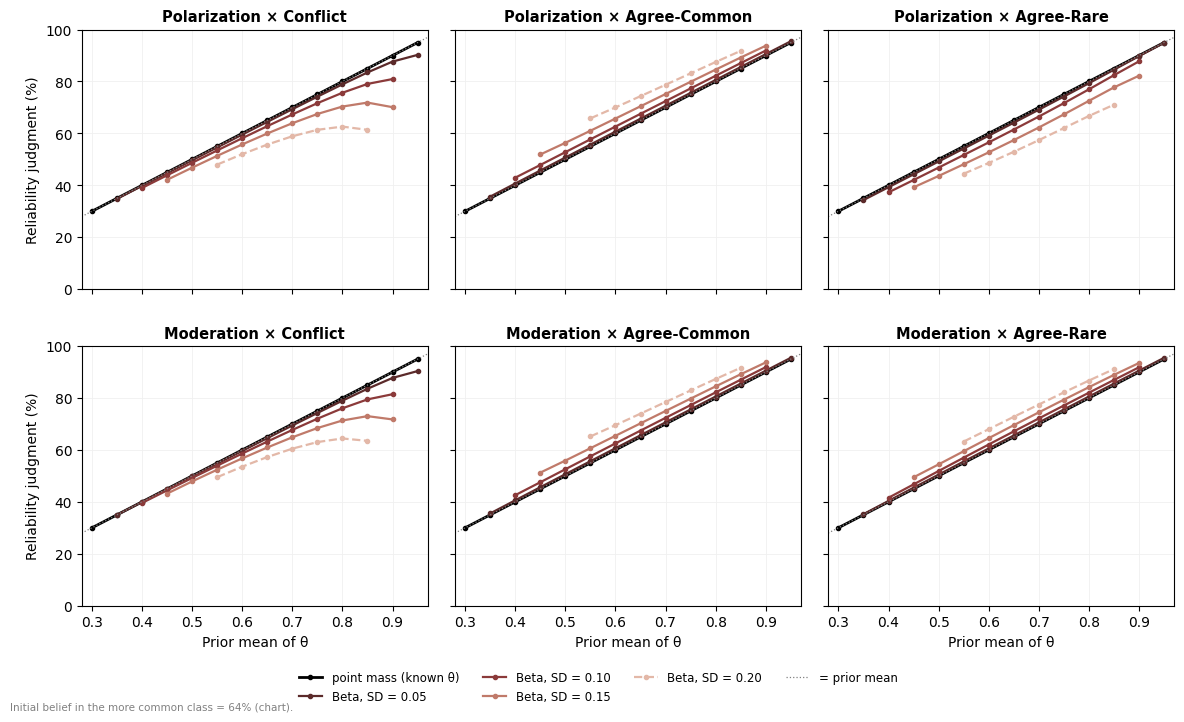

In [10]:
fig = plot_vs_prior_mean(chart_preds, "Reliability_final", "Reliability judgment (%)", reference="identity",
                         fname="JernRep-Study2-Normative-Reliability-byPrior.png")

**Reading Step 3.** All numbers below start from the chart (64%).

*Final belief is set mainly by the prior **mean** of θ.*

- **Polarization × Conflict.** The more reliable the observer thinks the test
  is, the further belief moves toward the more common class. It goes from 64%
  to 79% at a mean of 0.5 and to 95% at 0.9 when θ is known. This is the
  polarization effect.
- **Moderation × Conflict.** Belief moves the other way: 51% at a mean of 0.5,
  42% at 0.9.
- **Agree cells.** Beliefs move much further. At a mean of 0.7, Moderation ×
  Agree-Common falls to about 4%, and Polarization × Agree-Common and
  Moderation × Agree-Rare rise above 96%.
- **Polarization × Agree-Rare.** Here the prior mean matters most. Two results
  naming a disease with a 1% base rate leave belief near 59% if the test is
  thought to be a coin flip (mean 0.5). If it is thought to be very reliable
  (mean 0.9), belief falls to 8% when θ is known, and less far the more
  uncertain the observer is (14% at SD 0.10).

*The prior **SD** of θ matters for belief only where the results are
surprising.*

- In both Conflict cells and in Polarization × Agree-Rare, an uncertain observer
  updates less than one who knows θ, because part of the surprise is absorbed as
  doubt about the test. At a mean of 0.9, Polarization × Conflict reaches 94.7%
  with θ known but 91.5% with SD 0.10. Polarization × Agree-Rare reaches 7.7%
  vs. 13.7%.
- In the other three Agree cells, final belief at a given mean is nearly
  unaffected by the SD (within about 0.5 points).

*The reliability judgment has three properties:*

- **Known θ: the same answer in every cell.** An observer who knows θ reports
  θ in every cell and at every initial belief.
- **Uncertain θ: evidence-dependent answers.** An uncertain observer's answer
  depends on the results.
  - It **rises** above the prior mean after Agree-Common evidence (both pairs)
    and after Moderation × Agree-Rare.
  - It **falls** after both Conflict cells and after Polarization × Agree-Rare.
  - For example, at mean 0.7 and SD 0.10 it runs from 66.5% (Polarization ×
    Agree-Rare) to 72.4% (Agree-Common).
- **The size of the shift grows with the SD.** At mean 0.7 the reliability
  change in Polarization × Conflict is −0.7, −2.7, −6.1, and −11.1 points for
  SD 0.05, 0.10, 0.15, and 0.20. After Agree-Common it is +0.6, +2.4, +5.2, and
  +8.7.
  - Conflict lowers inferred reliability most when the prior mean is high:
    −9 points at mean 0.9, SD 0.10. That is when a conflict is most surprising.

Taken together, the level of the reliability judgment carries information about
the prior mean, and its differences between cells carry information about the
prior SD. Belief updates constrain the mean too, and the SD through the Conflict
and Polarization × Agree-Rare cells.

## Predicted responses as participants would enter them

Predictions above are stated for the more common class. The table below converts
one example prior into the four raw screen responses (2 chart versions × 2
question framings). This is what the reverse-coding in data processing has to
undo.

In [11]:
example = chart_preds[(chart_preds["prior_mean"] == 0.7) & (chart_preds["prior_sd"] == 0.1)].set_index("Cell")
raw_rows = []
for cell in CELL_ORDER:
    for v in CHART_VERSIONS:
        for q in ["allozedic", "hypozedic"]:
            raw_rows.append({"Cell": cell, "ChartVersion": v, "QuestionClass": q,
                             "Initial (raw)": to_raw_belief([example.loc[cell, "Belief_initial"]], [q], [v])[0],
                             "Final (raw)": to_raw_belief([example.loc[cell, "Belief_final"]], [q], [v])[0],
                             "Reliability": example.loc[cell, "Reliability_final"]})
print("Example prior: mean 0.70, SD 0.10")
pd.DataFrame(raw_rows).set_index(["Cell", "ChartVersion", "QuestionClass"]).round(1).head(8)

Example prior: mean 0.70, SD 0.10


Initial (raw)  \
Cell                        ChartVersion     QuestionClass                  
Polarization × Conflict     Hypozedic-common allozedic               36.0   
                                             hypozedic               64.0   
                            Allozedic-common allozedic               64.0   
                                             hypozedic               36.0   
Polarization × Agree-Common Hypozedic-common allozedic               36.0   
                                             hypozedic               64.0   
                            Allozedic-common allozedic               64.0   
                                             hypozedic               36.0   

                                                            Final (raw)  \
Cell                        ChartVersion     QuestionClass                
Polarization × Conflict     Hypozedic-common allozedic             13.4   
                                             hypozedic             86.6   
                            Allozedic-common allozedic             86.6   
                                             hypozedic             13.4   
Polarization × Agree-Common Hypozedic-common allozedic              1.9   
                                             hypozedic             98.1   
                            Allozedic-common allozedic             98.1   
                                             hypozedic              1.9   

                                                            Reliability  
Cell                        ChartVersion     QuestionClass               
Polarization × Conflict     Hypozedic-common allozedic             67.3  
                                             hypozedic             67.3  
                            Allozedic-common allozedic             67.3  
                                             hypozedic             67.3  
Polarization × Agree-Common Hypozedic-common allozedic             72.4  
                                             hypozedic             72.4  
                            Allozedic-common allozedic             72.4  
                                             hypozedic             72.4

# Step 4: Conditioning on initial beliefs

Participants will not all start at the chart's 64%. As in the Study 1 R pipeline
(`JernRep-ModelPredictions.qmd`, "initialized with participants' actual priors"),
the disease prior is the chart rescaled so that its class total equals an observed
initial belief. The within-class ratios stay at the chart's values. Two uses:

- **Curves** across initial beliefs (below), for reading predictions at the
  individual level.
- **`predict_from_emmeans`**, which takes a table of per-cell estimated marginal
  means of the reverse-coded initial belief (0–100%) and returns the normative
  predictions for every θ prior. On the new scale an emmean converts to a
  probability as `emmean / 100`. No slider conversion is needed.

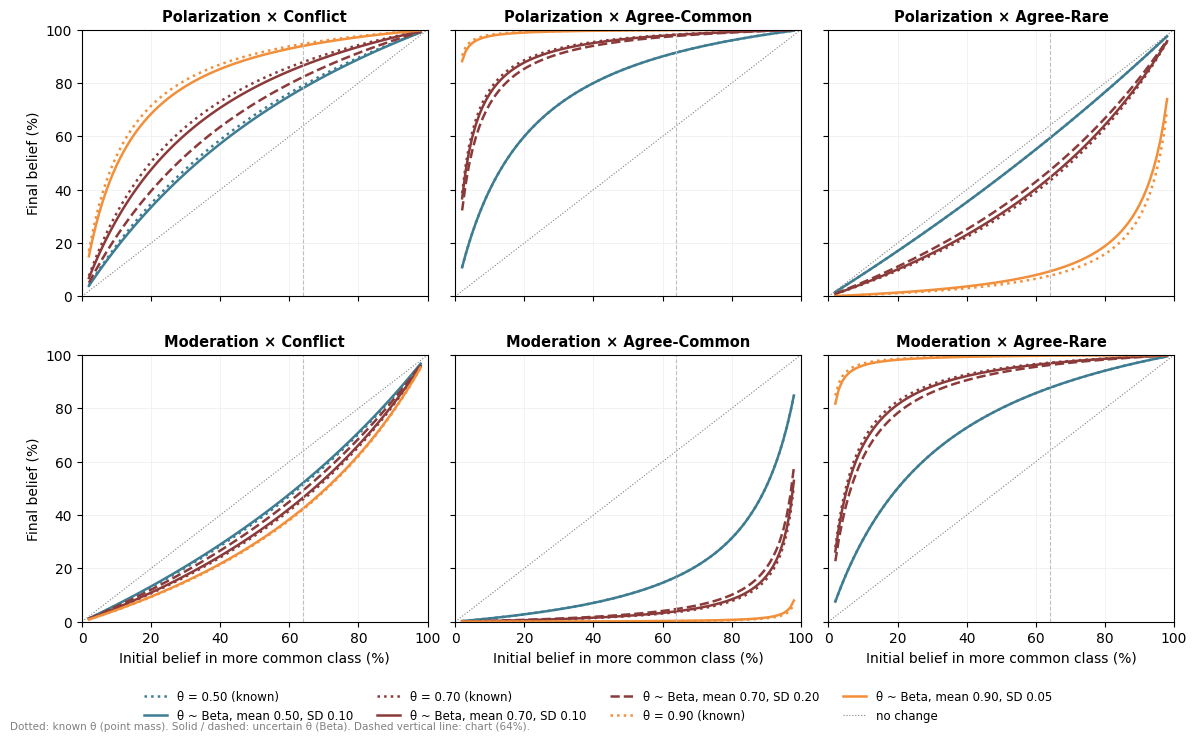

In [12]:
INITIAL_GRID = np.round(np.arange(0.02, 0.99, 0.01), 2)
CURVE_PRIORS = [p for p in theta_priors if (p["mean"], p["sd"]) in
                {(0.5, 0.0), (0.5, 0.1), (0.7, 0.0), (0.7, 0.1), (0.7, 0.2), (0.9, 0.0), (0.9, 0.05)}]
curve_preds = predictions_for(INITIAL_GRID, priors=CURVE_PRIORS)
CURVE_STYLE = {  ## (mean, sd) -> (color, linestyle)
    (0.5, 0.0): (TEAL, ":"), (0.5, 0.1): (TEAL, "-"),
    (0.7, 0.0): (RUST, ":"), (0.7, 0.1): (RUST, "-"), (0.7, 0.2): (RUST, "--"),
    (0.9, 0.0): (ORANGE, ":"), (0.9, 0.05): (ORANGE, "-"),
}


def plot_curves(df, dv, ylabel, identity=False, fname=None):
    fig, axes = plt.subplots(2, 3, figsize=(12, 7.4), sharex=True, sharey=True)
    for r_i, pair in enumerate(PAIR_ORDER):
        for c_i, ev in enumerate(EVIDENCE_ORDER):
            ax, cell = axes[r_i, c_i], f"{pair} × {ev}"
            for (m, s), (color, ls) in CURVE_STYLE.items():
                sub = df[(df["Cell"] == cell) & (df["prior_mean"] == m) & (df["prior_sd"] == s)]
                label = f"θ = {m:.2f} (known)" if s == 0 else f"θ ~ Beta, mean {m:.2f}, SD {s:.2f}"
                ax.plot(sub["Belief_initial"], sub[dv], color=color, ls=ls, lw=1.8, label=label)
            if identity:
                ax.plot([0, 100], [0, 100], color="gray", ls=":", lw=0.8, label="no change")
            ax.axvline(to_pct(P_COMMON_CHART), color="0.75", lw=0.8, ls="--")
            ax.set_title(cell, fontsize=10.5, fontweight="bold")
            ax.set_xlim(0, 100); ax.set_ylim(0, 100)
            ax.grid(color="0.94", lw=0.6); ax.set_axisbelow(True)
            if r_i == 1:
                ax.set_xlabel("Initial belief in more common class (%)")
        axes[r_i, 0].set_ylabel(ylabel)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, 0.0))
    fig.text(0.01, 0.005, "Dotted: known θ (point mass). Solid / dashed: uncertain θ (Beta). "
             "Dashed vertical line: chart (64%).", fontsize=7.5, color="gray")
    fig.subplots_adjust(bottom=0.15, left=0.07, right=0.98, top=0.95, hspace=0.22, wspace=0.08)
    if SAVE_FIGURES and fname:
        fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches="tight")
    return fig


fig = plot_curves(curve_preds, "Belief_final", "Final belief (%)", identity=True,
                  fname="JernRep-Study2-Normative-Belief-byInitial.png")

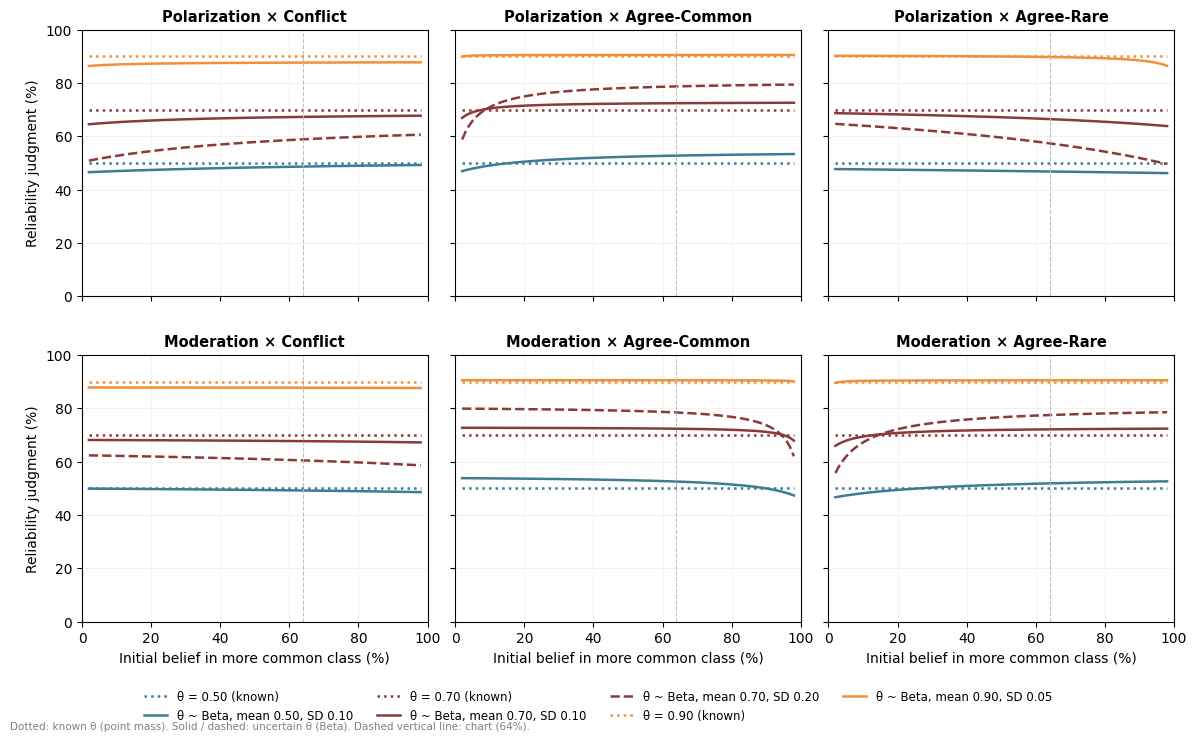

In [13]:
fig = plot_curves(curve_preds, "Reliability_final", "Reliability judgment (%)",
                  fname="JernRep-Study2-Normative-Reliability-byInitial.png")

**Reading Step 4.**

*Belief.* The curves bend the way Bayesian updating predicts. The same pair of
results moves an observer less the more firmly they already hold a belief. So
the same θ prior implies different belief changes for participants who start at
different points. This is why predictions are conditioned on the initial belief,
per participant or through the per-cell emmean, rather than on the chart alone.

*Reliability.* For an uncertain observer, the direction of the reliability shift
depends on how expected the results were given the observer's own initial
belief. For the uncertain priors plotted:

- **Always falls:** both Conflict cells, and Polarization × Agree-Rare at the
  lower prior means.
- **Rises, except at extreme initial beliefs:**
  - Polarization × Agree-Common: falls only below roughly 2–15%.
  - Moderation × Agree-Rare: falls only below roughly 4–26%.
  - Moderation × Agree-Common: falls only above roughly 89–94%, because A2 is in
    the less common class.

The crossover points move with the prior. Across the range where most
participants are likely to start, the direction is stable.

In [14]:
def predict_from_emmeans(emmeans_initial, priors=theta_priors):
    ## emmeans_initial: DataFrame with columns Cell and emmean (reverse-coded Initial, 0..100%).
    ## Returns the normative predictions for every theta prior, starting each cell from its emmean.
    out = []
    for _, row in emmeans_initial.iterrows():
        out.append(predictions_for(from_pct(row["emmean"]), priors=priors, cells=[row["Cell"]]))
    return pd.concat(out, ignore_index=True)


## Usage example with PLACEHOLDER emmeans (every cell at the chart value). Replace with the Study 2
## emmeans table once data exist, e.g. pd.read_csv(OUT_DIR / "<Study 2 emmeans file>.csv").
placeholder_emmeans = pd.DataFrame({"Cell": CELL_ORDER, "emmean": to_pct(P_COMMON_CHART)})
emm_preds = predict_from_emmeans(placeholder_emmeans)
keys = ["prior_mean", "prior_sd", "Cell"]
merged = emm_preds.merge(chart_preds, on=keys, suffixes=("_emm", "_chart"))
assert len(merged) == len(chart_preds)
assert np.allclose(merged["Belief_final_emm"], merged["Belief_final_chart"])
assert np.allclose(merged["Reliability_final_emm"], merged["Reliability_final_chart"])
print("predict_from_emmeans with chart-valued placeholders reproduces the Step 3 predictions.")

predict_from_emmeans with chart-valued placeholders reproduces the Step 3 predictions.


# Step 5: Why this design can recover the θ prior

In Study 1, conflicting results could not tell a known θ apart from an uncertain
one. For two conflicting results, the likelihood depends on the θ prior only
through

    r = E[θ(1 − θ)] / E[(1 − θ)²],

so every θ prior with the same r predicts the same belief update (the "ridge" in
`JernRep-BayesNetModels.ipynb`). That argument does not depend on the response
scale or the chart, so it holds in the Study 2 Conflict cells too.

Study 2 adds two things that break the tie:

- **Agreeing results.** The likelihood of two agreeing results involves E[θ²],
  a different moment of the prior.
- **The reliability judgment.** It reads E[θ | results] directly.

The demonstration takes an illustrative known reliability θ₀ and builds several
Beta priors with the same r. It then checks where their predictions coincide and
where they separate. The value of θ₀ is illustrative; the second table repeats the
check for several values.

In [15]:
LOG_A_BRACKET = (np.log(1e-4), np.log(1e4))


def evidence_ratio(theta_prior):
    ## r = E[theta (1 - theta)] / E[(1 - theta)^2] (JernRep-BayesNetModels.ipynb)
    grid, weights = theta_prior
    w = np.asarray(weights, dtype=float) / np.sum(weights)
    return float(np.sum(w * grid * (1 - grid)) / np.sum(w * (1 - grid) ** 2))


def ridge_member(r_target, b, grid=THETA_GRID):
    ## a such that Beta(a, b) on grid has evidence ratio r_target, or None if no a works
    f = lambda log_a: evidence_ratio(beta_prior(np.exp(log_a), b, grid)) - r_target
    if f(LOG_A_BRACKET[0]) > 0:
        return None
    return float(np.exp(brentq(f, *LOG_A_BRACKET)))


def ridge_priors(theta0, b_values=(1.5, 2, 3, 5, 10, 30)):
    ## Point mass at theta0 plus every Beta(a, b) on the same ridge
    r = theta0 / (1 - theta0)
    out = [("point mass", point_mass_prior(theta0))]
    for b in b_values:
        a = ridge_member(r, b)
        if a is not None:
            out.append((f"Beta({a:.2f}, {b:g})", beta_prior(a, b)))
    return out


THETA0_DEMO = 0.6
demo = ridge_priors(THETA0_DEMO)
demo_rows = []
for label, tp in demo:
    mean, sd = prior_moments(tp)
    row = {"Prior": label, "prior mean": mean, "prior sd": sd, "r": evidence_ratio(tp)}
    for cell in CELL_ORDER:
        out = predict_batch(cell, P_COMMON_CHART, tp)
        row[("Belief", cell)] = to_pct(out["p_final"][0])
        row[("Reliability", cell)] = to_pct(out["rel_final"][0])
    demo_rows.append(row)
demo_table = pd.DataFrame(demo_rows).set_index("Prior")
print(f"Priors on the ridge through a known θ₀ = {THETA0_DEMO} (initial belief 64%)")
demo_table[["prior mean", "prior sd", "r"]].round(3)

Priors on the ridge through a known θ₀ = 0.6 (initial belief 64%)


,prior mean,prior sd,r
Prior,,,
point mass,0.600,0.000,1.5
"Beta(3.47, 1.5)",0.707,0.177,1.5
"Beta(4.30, 2)",0.688,0.166,1.5
"Beta(5.89, 3)",0.665,0.147,1.5
"Beta(8.97, 5)",0.642,0.123,1.5
"Beta(16.50, 10)",0.623,0.092,1.5
"Beta(46.50, 30)",0.608,0.055,1.5


In [16]:
belief_cols = [c for c in demo_table.columns if isinstance(c, tuple) and c[0] == "Belief"]
rel_cols = [c for c in demo_table.columns if isinstance(c, tuple) and c[0] == "Reliability"]
print("Final belief (%) under each ridge prior")
demo_table[belief_cols].set_axis([c[1] for c in belief_cols], axis=1).round(2)

Final belief (%) under each ridge prior


,Polarization × Conflict,Polarization × Agree-Common,Polarization × Agree-Rare,Moderation × Conflict,Moderation × Agree-Common,Moderation × Agree-Rare
Prior,,,,,,
point mass,83.78,95.86,53.67,48.29,8.27,93.59
"Beta(3.47, 1.5)",83.78,97.87,45.78,48.29,4.29,96.59
"Beta(4.30, 2)",83.78,97.60,47.38,48.29,4.82,96.18
"Beta(5.89, 3)",83.78,97.24,49.18,48.29,5.54,95.63
"Beta(8.97, 5)",83.78,96.83,50.82,48.29,6.35,95.02
"Beta(16.50, 10)",83.78,96.42,52.19,48.29,7.18,94.40
"Beta(46.50, 30)",83.78,96.07,53.17,48.29,7.87,93.89


In [17]:
print("Reliability judgment (%) under each ridge prior")
demo_table[rel_cols].set_axis([c[1] for c in rel_cols], axis=1).round(2)

Reliability judgment (%) under each ridge prior


,Polarization × Conflict,Polarization × Agree-Common,Polarization × Agree-Rare,Moderation × Conflict,Moderation × Agree-Common,Moderation × Agree-Rare
Prior,,,,,,
point mass,60.00,60.00,60.00,60.00,60.00,60.00
"Beta(3.47, 1.5)",61.90,77.65,60.31,63.20,77.44,76.70
"Beta(4.30, 2)",61.68,75.06,59.58,62.83,74.86,74.15
"Beta(5.89, 3)",61.36,71.67,59.06,62.29,71.49,70.85
"Beta(8.97, 5)",60.97,68.04,58.96,61.64,67.90,67.39
"Beta(16.50, 10)",60.55,64.49,59.25,60.93,64.40,64.08
"Beta(46.50, 30)",60.20,61.62,59.69,60.34,61.58,61.45


In [18]:
## How far apart the ridge priors are, cell by cell, across several known theta0 values and initial beliefs
spread_rows = []
for theta0 in [0.4, 0.5, 0.6, 0.7, 0.8]:
    fam = ridge_priors(theta0)
    for p0 in [0.5, P_COMMON_CHART, 0.8]:
        for cell in CELL_ORDER:
            outs = [predict_batch(cell, p0, tp) for _, tp in fam]
            bel = to_pct([o["p_final"][0] for o in outs]); rel = to_pct([o["rel_final"][0] for o in outs])
            spread_rows.append({"θ₀": theta0, "Initial (%)": round(to_pct(p0)), "Cell": cell,
                                "Belief spread": bel.max() - bel.min(), "Reliability spread": rel.max() - rel.min()})
ridge_spread = pd.DataFrame(spread_rows)
print("Max − min across ridge priors (percentage points)")
ridge_spread.pivot_table(index="Cell", columns="θ₀", values=["Belief spread", "Reliability spread"],
                         aggfunc="max", sort=False).reindex(CELL_ORDER).round(2)

Max − min across ridge priors (percentage points)


Belief spread                             \
θ₀                                    0.4    0.5   0.6    0.7    0.8   
Cell                                                                   
Polarization × Conflict              0.00   0.00  0.00   0.00   0.00   
Polarization × Agree-Common          6.67   6.22  3.41   1.48   0.49   
Polarization × Agree-Rare            1.34   4.39  7.89  10.62  12.06   
Moderation × Conflict                0.00   0.00  0.00   0.00   0.00   
Moderation × Agree-Common           10.59  12.41  7.71   3.60   1.24   
Moderation × Agree-Rare              6.59   7.86  4.94   2.32   0.80   

                            Reliability spread                             
θ₀                                         0.4    0.5    0.6    0.7   0.8  
Cell                                                                       
Polarization × Conflict                   1.92   2.85   2.66   1.86  0.92  
Polarization × Agree-Common              14.16  20.15  17.94  13.63  8.82  
Polarization × Agree-Rare                 2.17   3.17   2.64   4.80  5.74  
Moderation × Conflict                     2.86   4.05   3.64   2.46  1.19  
Moderation × Agree-Common                14.03  20.07  17.91  13.62  8.82  
Moderation × Agree-Rare                  11.49  18.43  17.17  13.34  8.75

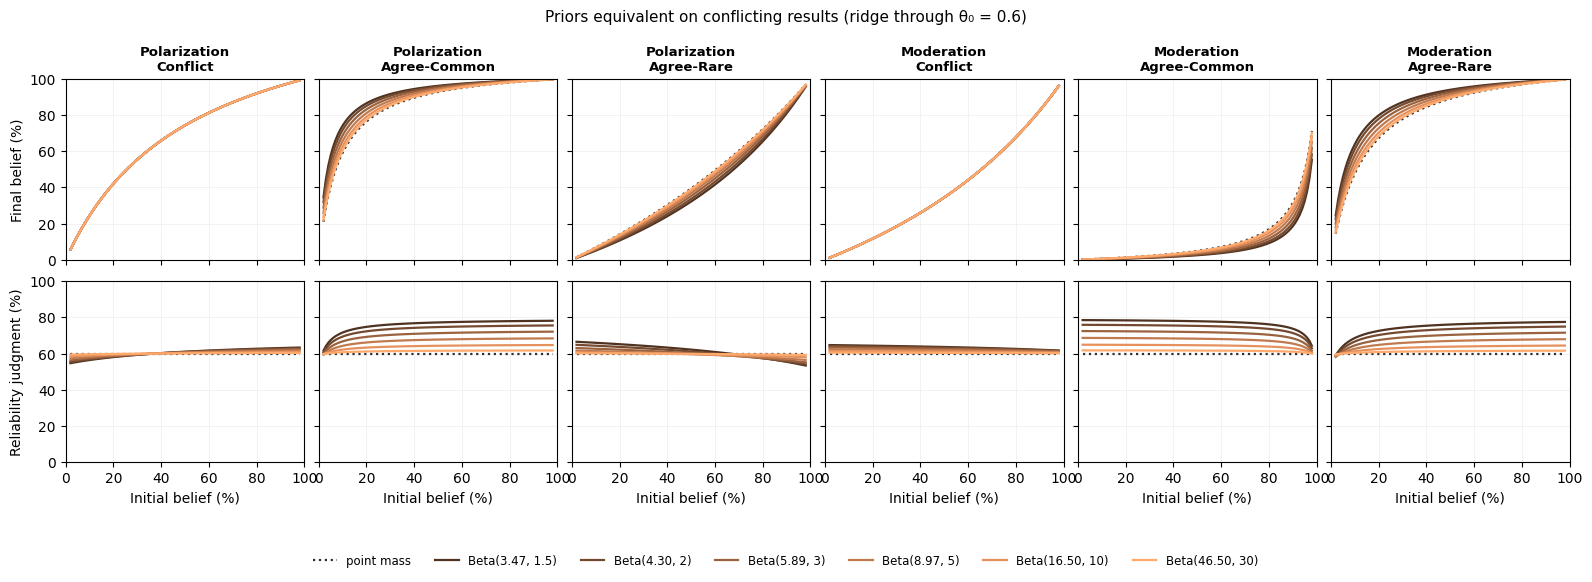

In [19]:
## Figure: belief and reliability across initial beliefs for the ridge priors at theta0 = THETA0_DEMO
ridge_colors = [INK] + list(plt.cm.copper(np.linspace(0.25, 0.85, len(demo) - 1)))
fig, axes = plt.subplots(2, 6, figsize=(16, 5.8), sharex=True)
x = to_pct(INITIAL_GRID)
for c_i, cell in enumerate(CELL_ORDER):
    for (label, tp), color in zip(demo, ridge_colors):
        out = predict_batch(cell, INITIAL_GRID, tp)
        ls = ":" if label == "point mass" else "-"
        axes[0, c_i].plot(x, to_pct(out["p_final"]), color=color, ls=ls, lw=1.6, label=label)
        axes[1, c_i].plot(x, to_pct(out["rel_final"]), color=color, ls=ls, lw=1.6, label=label)
    axes[0, c_i].set_title(cell.replace(" × ", "\n"), fontsize=9.5, fontweight="bold")
    for r_i in range(2):
        axes[r_i, c_i].set_xlim(0, 100); axes[r_i, c_i].set_ylim(0, 100)
        axes[r_i, c_i].grid(color="0.94", lw=0.6); axes[r_i, c_i].set_axisbelow(True)
        if c_i > 0:
            axes[r_i, c_i].tick_params(labelleft=False)
    axes[1, c_i].set_xlabel("Initial belief (%)")
axes[0, 0].set_ylabel("Final belief (%)")
axes[1, 0].set_ylabel("Reliability judgment (%)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(demo), frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, 0.0))
fig.suptitle(f"Priors equivalent on conflicting results (ridge through θ₀ = {THETA0_DEMO})", fontsize=11)
fig.subplots_adjust(bottom=0.2, left=0.05, right=0.99, top=0.86, hspace=0.12, wspace=0.06)
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "JernRep-Study2-Normative-Ridge.png", dpi=300, bbox_inches="tight")

**Reading Step 5.** The priors in the demonstration table are all equivalent
on conflicting results. A known θ₀ = 0.6 and six Beta priors with prior means from
0.61 to 0.71 share r = 1.5.

- **Conflict cells: no separation on belief.** They predict identical final
  beliefs in both Conflict cells (83.78% and 48.29%). The same holds at every
  initial belief, as the figure shows. On belief, the Conflict cells cannot tell
  these priors apart.
- **Agree cells: separation on belief.** Final beliefs differ. At θ₀ = 0.6 the
  spread is about 8 points in Polarization × Agree-Rare, 4 in Moderation ×
  Agree-Common, 3 in Moderation × Agree-Rare, and 2 in Polarization ×
  Agree-Common. Which Agree cell separates the priors most depends on θ₀:
  - Moderation × Agree-Common for θ₀ ≤ 0.5 (about 11–12 points);
  - Polarization × Agree-Rare for θ₀ ≥ 0.6 (about 8–12 points).

  This is a reason to keep both Agree types in both pairs.
- **The reliability judgment separates them most.** The known-θ₀ observer says
  60% everywhere. The Beta observers say up to about 78% after Agree-Common
  evidence. Across θ₀ from 0.4 to 0.8 the spread is 9–20 points in the
  Agree-Common cells and in Moderation × Agree-Rare, and at most about 4 points
  in the Conflict cells.

So the three additions in Study 2 work together to make the θ prior
recoverable: agreeing trials, the reliability question, and the conflicting
trials alongside them. The Conflict cells pin down r, the Agree cells add a
second moment of the prior, and the reliability judgment reads the posterior
mean directly.

# Export

| File | Contents |
|---|---|
| `JernRep-Study2-NormativePredictions-ChartPrior.csv` | every θ prior × cell, starting from the chart (Step 3) |
| `JernRep-Study2-NormativePredictions-ByInitial.csv` | selected θ priors × cell × initial belief 2–98% (Step 4) |
| `JernRep-Study2-NormativePredictions-RidgeSpread.csv` | ridge-prior spreads by θ₀, initial belief, and cell (Step 5) |
| `JernRep-Study2-NormativePredictions-ThetaPriors.csv` | the candidate θ priors: family, a, b, mean, SD |
| `JernRep-Study2-Design-ResponseMap.csv` | the 48 counterbalancing combinations and which need reverse-coding |

In [20]:
exports = {
    "JernRep-Study2-NormativePredictions-ChartPrior.csv": chart_preds,
    "JernRep-Study2-NormativePredictions-ByInitial.csv": curve_preds,
    "JernRep-Study2-NormativePredictions-RidgeSpread.csv": ridge_spread,
    "JernRep-Study2-NormativePredictions-ThetaPriors.csv": prior_table,
    "JernRep-Study2-Design-ResponseMap.csv": design_map,
}
for fname, frame in exports.items():
    if SAVE_CSV:
        frame.to_csv(OUT_DIR / fname, index=False)
    print(f"{'wrote' if SAVE_CSV else 'skipped'} {fname:<55} {len(frame):>6,} rows")

wrote JernRep-Study2-NormativePredictions-ChartPrior.csv         330 rows
wrote JernRep-Study2-NormativePredictions-ByInitial.csv        4,074 rows
wrote JernRep-Study2-NormativePredictions-RidgeSpread.csv         90 rows
wrote JernRep-Study2-NormativePredictions-ThetaPriors.csv         55 rows
wrote JernRep-Study2-Design-ResponseMap.csv                       48 rows
